# astrowidget — Interactive Sky Viewer

Replaces ipyaladin for OVRO-LWA visualization. No FITS round-trip — zarr → numpy → GPU directly.

**What this replaces:**
| ipyaladin workflow | astrowidget workflow |
|---|---|
| Extract WCS from zarr attrs | Same |
| Build `astropy.io.fits.HDUList` from numpy | **Eliminated** |
| Serialize FITS to bytes | **Eliminated** |
| `aladin.add_fits(hdul)` | `widget.set_image(array, wcs)` |
| Broken sphere overlay | Working sphere overlay |

## Setup

Launch from the ovro-lwa-portal pixi environment:
```
pixi run jupyter lab
```

In [1]:
import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
load_dotenv()

import os
import ovro_lwa_portal as ovro

## 1. Load OVRO-LWA data from OSN

Same `open_dataset()` call as the interactive_viz_demo notebook.

In [2]:
# DOI for the 10t x 10f x 4096x4096 test dataset
#DOI = "10.33569/4q7nb-ahq31"
DOI = '/fast/claw/I-Deep-Taper-Robust-0-25Jan.zarr'

ds = ovro.open_dataset(
    DOI,
    production=False,
    storage_options={
        "key": os.environ["OSN_KEY"],
        "secret": os.environ["OSN_SECRET"],
    },
)

print(f"Loaded: {DOI}")
print(f"  Dims:  {dict(ds.dims)}")
print(f"  Vars:  {list(ds.data_vars)}")
print(f"  Freq:  {float(ds.frequency.values[0])/1e6:.1f} – {float(ds.frequency.values[-1])/1e6:.1f} MHz")
print(f"  WCS:   {ds.radport.has_wcs}")

Loaded: /fast/claw/I-Deep-Taper-Robust-0-25Jan.zarr
  Dims:  {'time': 11, 'frequency': 15, 'polarization': 1, 'beam_param': 3, 'l': 4096, 'm': 4096}
  Vars:  ['BEAM', 'SKY', 'wcs_header_str']
  Freq:  18.0 – 82.0 MHz
  WCS:   True


## 2. Display on the celestial sphere — one line

**Old way (ipyaladin):** Extract WCS, build FITS HDU, serialize, `aladin.add_fits()` — 20+ lines.

**New way:** `widget.set_dataset(ds)` — reads zarr, caches slices, extracts WCS, renders. One line.

In [3]:
from astrowidget import SkyWidget
from astropy.coordinates import SkyCoord
import astropy.units as u

widget = SkyWidget()

# One line: zarr → cached slices → WCS → GPU. No FITS anywhere.
widget.set_dataset(ds)

# Navigate to phase center with full hemisphere
from astrowidget import get_wcs
wcs = get_wcs(ds)
phase_center = SkyCoord(ra=wcs.wcs.crval[0], dec=wcs.wcs.crval[1], unit="deg", frame="fk5")
widget.goto(phase_center, fov=180 * u.deg)

print(f"Phase center: {phase_center.to_string('hmsdms')}")
print(f"vmin={widget.vmin:.2f}, vmax={widget.vmax:.2f}")
widget

Phase center: 02h53m54.99933128s +37d07m42.86821363s
vmin=-23.58, vmax=29.03


## 4. Navigate to known radio sources

Use `goto()` with any `SkyCoord` to navigate the sphere.

In [6]:
# Navigate to Cassiopeia A — brightest radio source in the northern sky
cas_a = SkyCoord.from_name("Cas A")
widget.goto(cas_a, fov=30 * u.deg)
print(f"Navigated to Cas A: {cas_a.to_string('hmsdms')}")

Navigated to Cas A: 23h23m26.016s +58d48m40.68s


In [7]:
# Navigate to Cygnus A
cyg_a = SkyCoord.from_name("Cyg A")
widget.goto(cyg_a, fov=20 * u.deg)
print(f"Navigated to Cyg A: {cyg_a.to_string('hmsdms')}")

Navigated to Cyg A: 19h59m28.35656837s +40d44m02.0972325s


In [8]:
# Back to full hemisphere
widget.goto(phase_center, fov=180 * u.deg)

## 5. Change display settings from Python

Colormap, stretch, and color scale are GPU-only updates — instant, no data re-upload.

In [9]:
# Colormap, stretch, grid — all instant GPU updates
widget.colormap = "viridis"
widget.stretch = "sqrt"
widget.auto_scale(percentile_low=5, percentile_high=95)
print(f"Grid: {widget.show_grid}")

# Toggle grid off/on
# widget.show_grid = False

Grid: True


In [10]:
# Switch slices via traitlets — observer auto-updates the display
widget.time_idx = 5
widget.freq_idx = 5
widget.colormap = "inferno"
widget.stretch = "linear"
freq_mhz = float(ds.coords["frequency"].values[widget.freq_idx]) / 1e6
print(f"Showing time={widget.time_idx}, freq={widget.freq_idx} ({freq_mhz:.1f} MHz)")

# Try other slices:
# widget.time_idx = 0
# widget.freq_idx = 9

Showing time=5, freq=5 (46.0 MHz)


## 6. Read view state from Python

After panning/zooming in the widget, read back the current view position.

In [11]:
# Read current view (updates after pan/zoom interaction)
print(f"View center: RA={widget.view_ra:.4f}°, Dec={widget.view_dec:.4f}°")
print(f"Field of view: {widget.view_fov:.2f}°")
print(f"Colormap: {widget.colormap}, Stretch: {widget.stretch}")
print(f"Color scale: [{widget.vmin:.2f}, {widget.vmax:.2f}]")

View center: RA=43.4792°, Dec=37.1286°
Field of view: 24.32°
Colormap: inferno, Stretch: linear
Color scale: [-1.58, 4.12]


## 7. Overlay radio data on DSS survey tiles

`widget.overlay("DSS")` stacks the SkyWidget on top of Aladin Lite.
The radio image is transparent where there's no data, so the optical sky shows through.

In [12]:
# Set background BEFORE displaying — Aladin loads in the same container
widget2 = SkyWidget()
widget2.set_dataset(ds)  # auto-navigates to phase center with fitted FOV
widget2.background_survey = "DSS"
widget2

In [13]:
# Switch survey
# widget2.background_survey = "Mellinger"
widget2.background_survey = "WISE"
# widget2.background_survey = ""  # disable

In [15]:
from astrowidget import SkyViewer


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
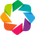

Row(sizing_mode='stretch_width')
    [0] Column(width=250)
        [0] IntSlider(end=7, name='Time')
        [1] IntSlider(end=13, name='Frequency')
        [2] Select(description='Colormap', name='Colormap', options=OrderedDict({'inferno': 'i...]), value='inferno')
        [3] Select(description='Stretch function', name='Stretch', options=OrderedDict({'linear': 'li...]), value='linear')
        [4] Checkbox(name='Grid', value=True)
        [5] Markdown(str)
        [6] Select(description='HiPS background s..., name='Background', options=OrderedDict({'': '', ...]))
        [7] FloatSlider(name='BG Opacity', step=0.05, value=1.0)
    [1] IPyWidget(SkyWidget, sizing_mode='stretch_both')
    [2] Column(min_width=350)
        [0] HoloViews(Curve, height=250, sizing_mode='stretch_width')
        [1] HoloViews(Curve, height=250, sizing_mode='stretch_width')

In [16]:
viewer = SkyViewer.from_zarr("/fast/claw/I-Deep-Taper-Robust-0-25Jan.zarr")
viewer.panel()